# Reavaliação do Dataset Iris com SVM
**Isabelli Reno** **|** **11241100124**

**Dataset:** [Iris Species (Kaggle)] (https://www.kaggle.com/datasets/menegidio/iris-species)

**Objetivo:** Construir um fluxo de Machine Learning utilizando o Support Vector Machine (SVM) para classificar espécies de flores da base Iris.

In [1]:
# Importação de bibliotecas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style = "whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Carregamento de Dados

In [2]:
# Caminho padrão do arquivo
import os
import pandas as pd

filepath = "/kaggle/input/iris-species/Iris.csv"

# Verificação de diretório
if not os.path.exists(filepath):
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            # Imprime apenas o arquivo .csv
            if filename.endswith('.csv'):
                filepath = os.path.join(dirname, filename)
                break # Para se corresponder

print(f'Arquivo de dados: {filepath}')
# Leitura
try:
    df = pd.read_csv(filepath, encoding = 'utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(filepath, encoding = 'latin1')
df.head()

Arquivo de dados: /kaggle/input/datasets/menegidio/iris-species/Iris.csv


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Análise Explorarória de Dados (EDA)

In [3]:
# Estatísticas
print('Dimensão do dataset:', df.shape)
print('\nInformações das colunas:')
print(df.info())

# Verificação da coluna Species, contém os rótulos
print('\nContagem por espécie:')
print(df['Species'].value_counts())

# Remove a coluna ID (caso exista)
if 'Id'in df.columns:
    df = df.drop(columns =['Id'])

df.describe()

Dimensão do dataset: (150, 6)

Informações das colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Contagem por espécie:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


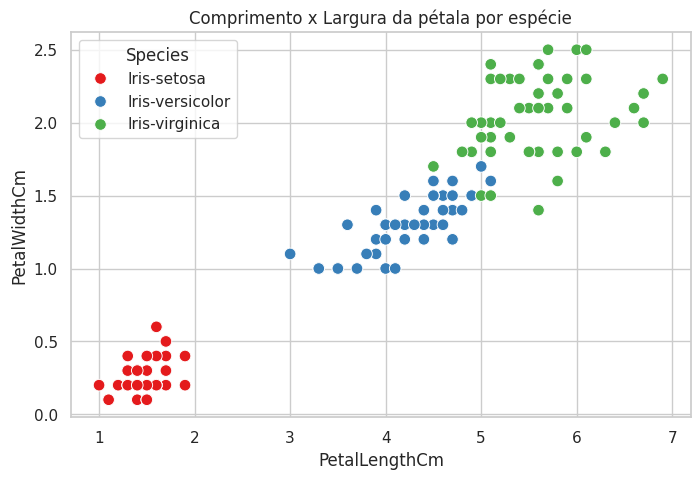

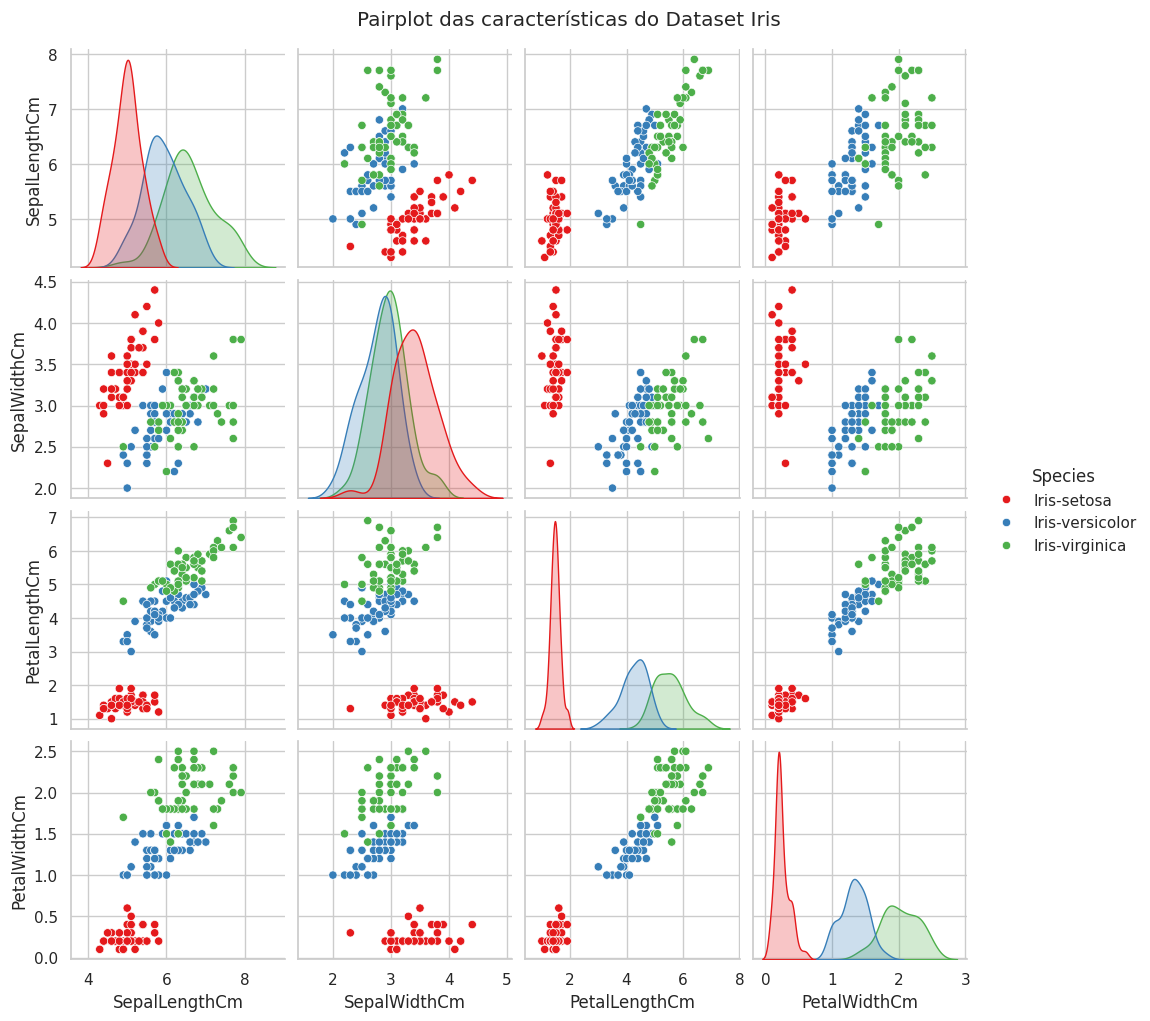

In [4]:
# Gráfico de dispersão entre as variáveis das pétalas
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = 'PetalLengthCm', y = 'PetalWidthCm', hue = 'Species', palette = 'Set1', s = 70)
plt.title('Comprimento x Largura da pétala por espécie')
plt.show()

# Pairplot geral (visualização de combinações)
sns.pairplot(df, hue = 'Species', palette = 'Set1')
plt.suptitle('Pairplot das características do Dataset Iris', y = 1.02)
plt.show()

## 3. Pré-processamento e Divisão de Dados

In [5]:
# Separação das Características e Rótulos
X = df.drop(columns = ['Species'])
y = df['Species']

# Divisão de Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

print(f'Formato X treino: {X_train.shape}')
print(f'Formato X teste: {X_test.shape}')

Formato X treino: (120, 4)
Formato X teste: (30, 4)


## 4. Treinamento e Avaliação do SVM

In [6]:
# SVM Linear
pipeline_linear = Pipeline([
    ('scalter', StandardScaler()),
    ('svm', SVC(kernel = 'linear', C = 1.0, random_state = 42))
])

pipeline_linear.fit(X_train, y_train)
y_pred_linear = pipeline_linear.predict(X_test)

print(f'Precisão SVM Linear: {accuracy_score(y_test, y_pred_linear):.4f}')
print('\nRelatório de classificação (linear):\n')
print(classification_report(y_test, y_pred_linear))

Precisão SVM Linear: 1.0000

Relatório de classificação (linear):

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [7]:
# SVM Não Linear com Kernel RBF
pipeline_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel = 'rbf', C = 1.0, gamma = 'scale', random_state = 42))
])

pipeline_rbf.fit(X_train, y_train)
y_pred_rbf = pipeline_rbf.predict(X_test)

print(f'Precisão do SVM RBF: {accuracy_score(y_test, y_pred_rbf):.4f}')
print('\nRelatório de Classificação (RBF):\n')
print(classification_report(y_test, y_pred_rbf))

Precisão do SVM RBF: 0.9667

Relatório de Classificação (RBF):

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



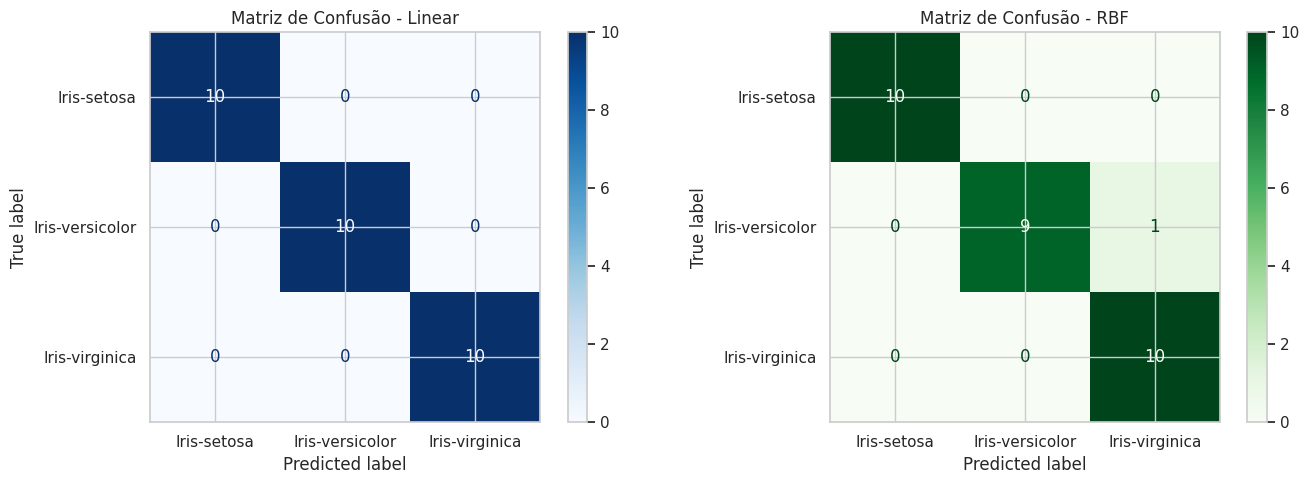

Acurácia Média CV (Linear): 0.9667 (+/- 0.0298)
Acurácia Média CV (RBF): 0.9667 (+/- 0.0211)


In [8]:
# Matriz de confusão do modelo RBF
fig, ax = plt.subplots(1, 2, figsize = (14, 5))

# Linear
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_linear, ax = ax[0], cmap = 'Blues')
ax[0].set_title('Matriz de Confusão - Linear')

# Não Linear
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rbf, ax = ax[1], cmap = 'Greens')
ax[1].set_title('Matriz de Confusão - RBF')

plt.tight_layout()
plt.show()

# Validação
cv_scores_linear = cross_val_score(pipeline_linear, X, y, cv = 5)
cv_scores_rbf = cross_val_score(pipeline_rbf, X, y, cv = 5)

print(f'Acurácia Média CV (Linear): {cv_scores_linear.mean():.4f} (+/- {cv_scores_linear.std():.4f})')
print(f'Acurácia Média CV (RBF): {cv_scores_rbf.mean():.4f} (+/- {cv_scores_rbf.std():.4f})')